In [21]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Set visualization style
sns.set(style="whitegrid")

In [22]:
# 2. Load Dataset

df = pd.read_excel("Sleep_health_and_lifestyle_dataset.xlsx")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80    

In [23]:
# 3. Feature Engineering: Blood Pressure

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

df.drop('Blood Pressure', axis=1, inplace=True)

In [24]:
# Encoding Categorical Variables

le = LabelEncoder()

categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

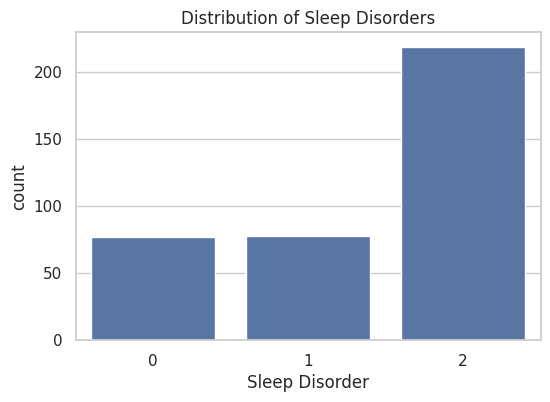

In [25]:
# 4.  Exploratory Data Analysis
# 4.1 Target Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Sleep Disorder', data=df)
plt.title("Distribution of Sleep Disorders")
plt.show()

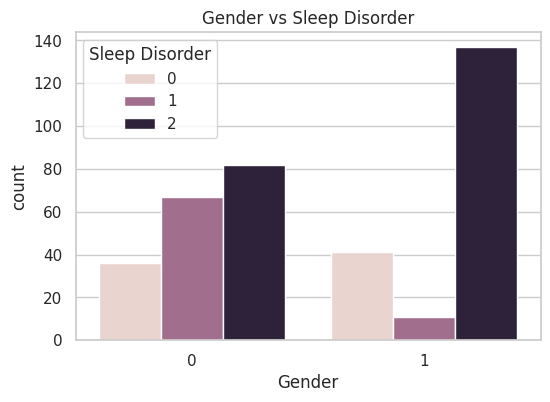

In [26]:
# 4.2 Gender vs Sleep Disorder

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Sleep Disorder', data=df)
plt.title("Gender vs Sleep Disorder")
plt.show()

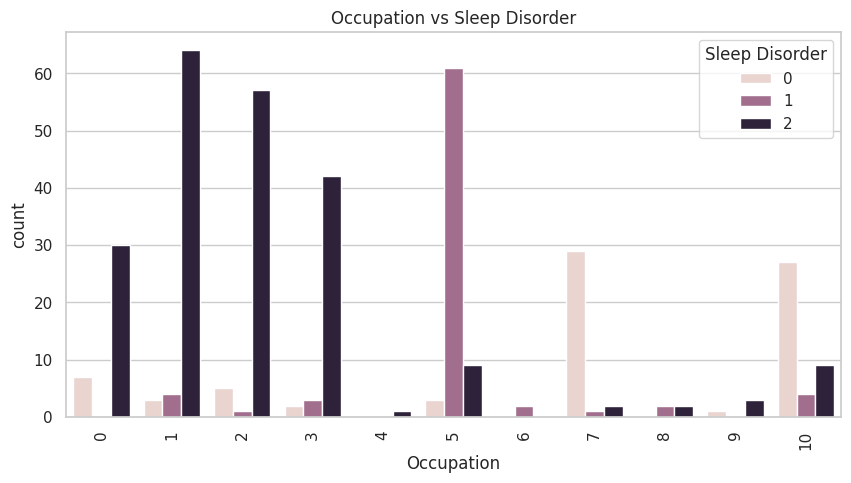

In [27]:
# 4.3 Occupation Impact

plt.figure(figsize=(10,5))
sns.countplot(x='Occupation', hue='Sleep Disorder', data=df)
plt.xticks(rotation=90)
plt.title("Occupation vs Sleep Disorder")
plt.show()

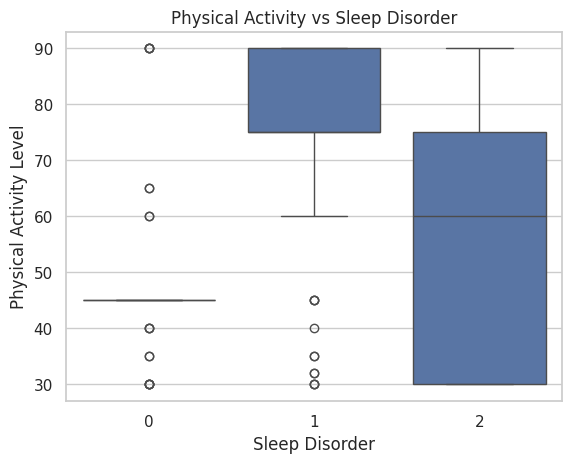

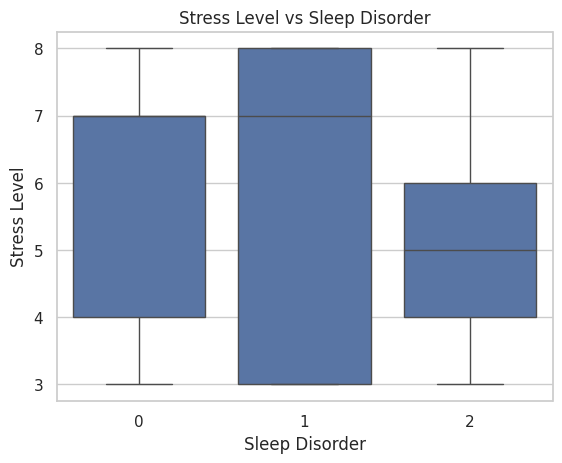

In [28]:
# 4.4 Lifestyle Factors Analysis

# Physical Activity
sns.boxplot(x='Sleep Disorder', y='Physical Activity Level', data=df)
plt.title("Physical Activity vs Sleep Disorder")
plt.show()

# Stress Level
sns.boxplot(x='Sleep Disorder', y='Stress Level', data=df)
plt.title("Stress Level vs Sleep Disorder")
plt.show()

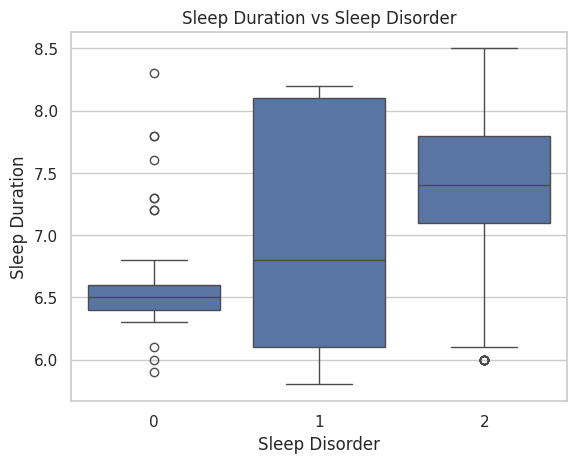

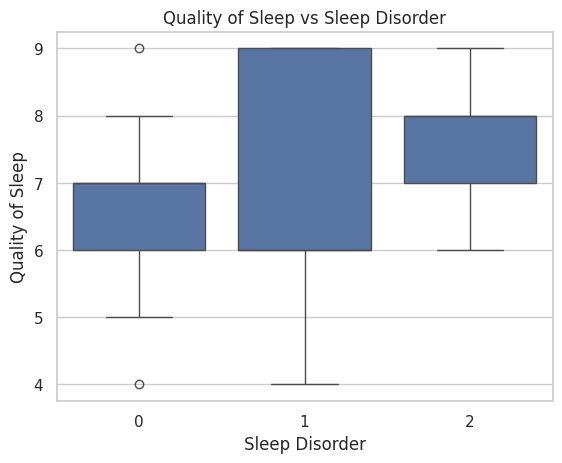

In [29]:
# 4.5 Sleep Duration & Quality

sns.boxplot(x='Sleep Disorder', y='Sleep Duration', data=df)
plt.title("Sleep Duration vs Sleep Disorder")
plt.show()

sns.boxplot(x='Sleep Disorder', y='Quality of Sleep', data=df)
plt.title("Quality of Sleep vs Sleep Disorder")
plt.show()

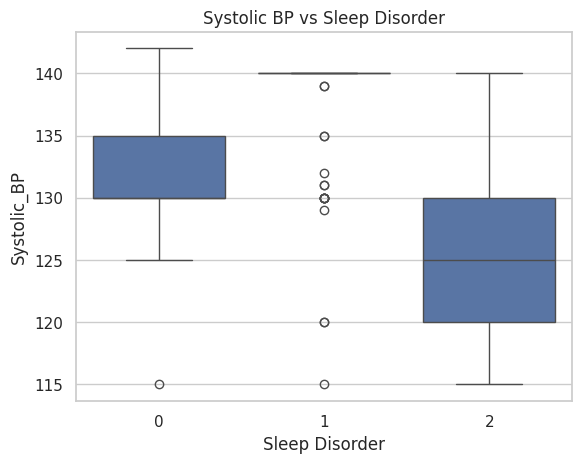

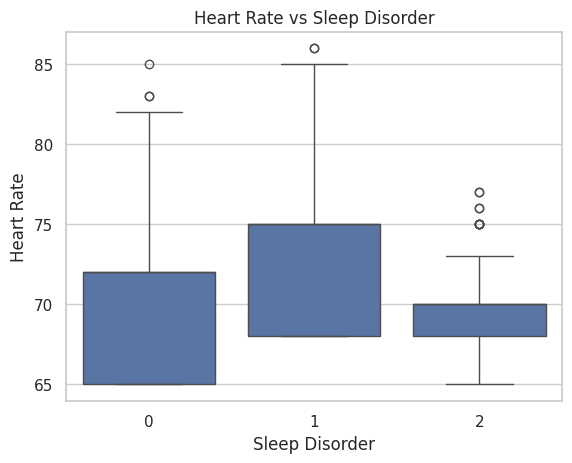

In [30]:
# 4.6 BMI & Cardiovascular Indicators

sns.boxplot(x='Sleep Disorder', y='Systolic_BP', data=df)
plt.title("Systolic BP vs Sleep Disorder")
plt.show()

sns.boxplot(x='Sleep Disorder', y='Heart Rate', data=df)
plt.title("Heart Rate vs Sleep Disorder")
plt.show()

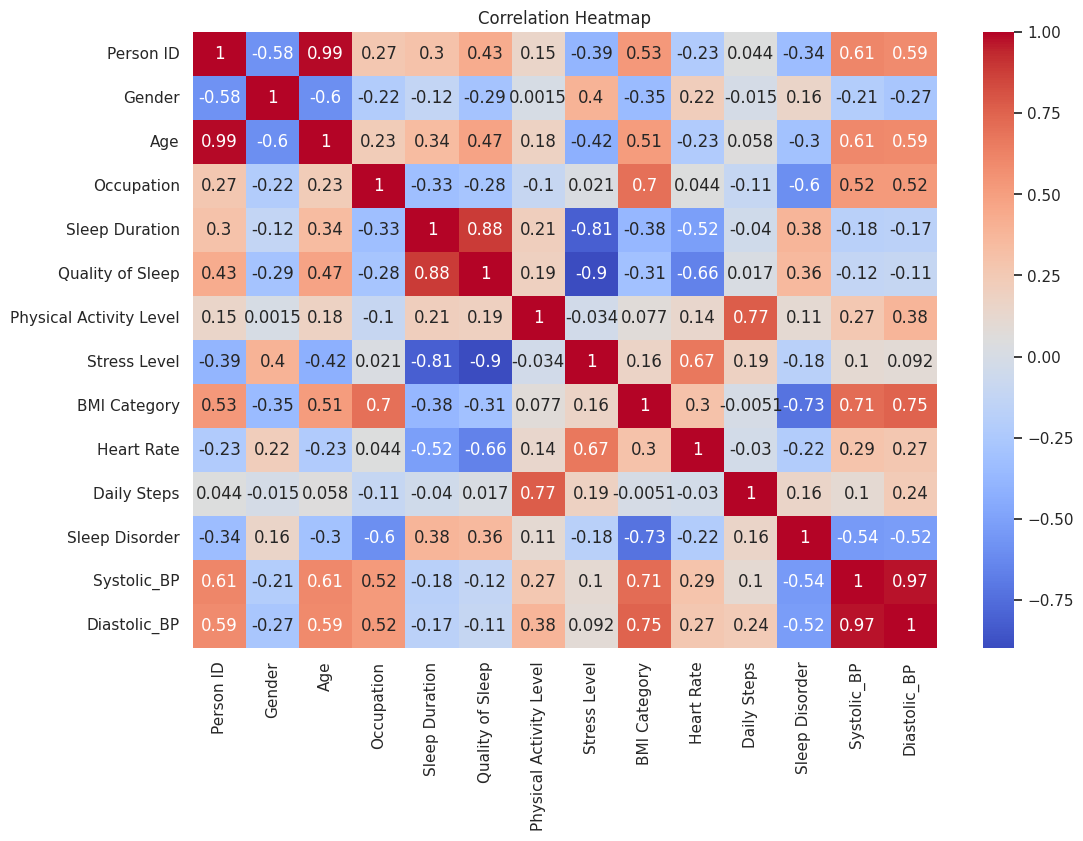

In [31]:
# 4.7 Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# 5. Define Features & Target

# Define X (Features) and y (Target)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

In [33]:
# 6. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
# 7. Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8933333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.79        16
           1       0.86      0.75      0.80        16
           2       0.95      0.98      0.97        43

    accuracy                           0.89        75
   macro avg       0.86      0.85      0.85        75
weighted avg       0.89      0.89      0.89        75



In [35]:
# 8. Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.85      0.69      0.76        16
           2       0.95      0.98      0.97        43

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



In [42]:
# 9. XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.88

Classification Report - XGBoost:

              precision    recall  f1-score   support

           0       0.72      0.81      0.76        16
           1       0.85      0.69      0.76        16
           2       0.95      0.98      0.97        43

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



In [38]:
# 10. Model Comparison

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.893333
1  Random Forest  0.880000
2        XGBoost  0.880000


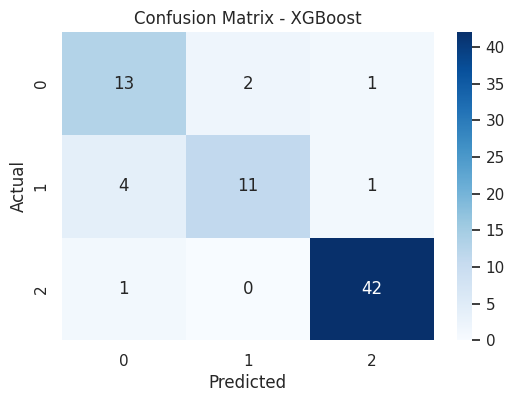

In [39]:
# 11. Confusion Matrix (XGBoost)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

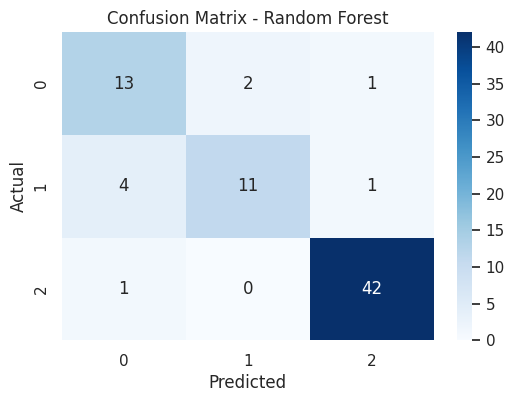

In [18]:
# 12. Confusion Matrix (Random Forest)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

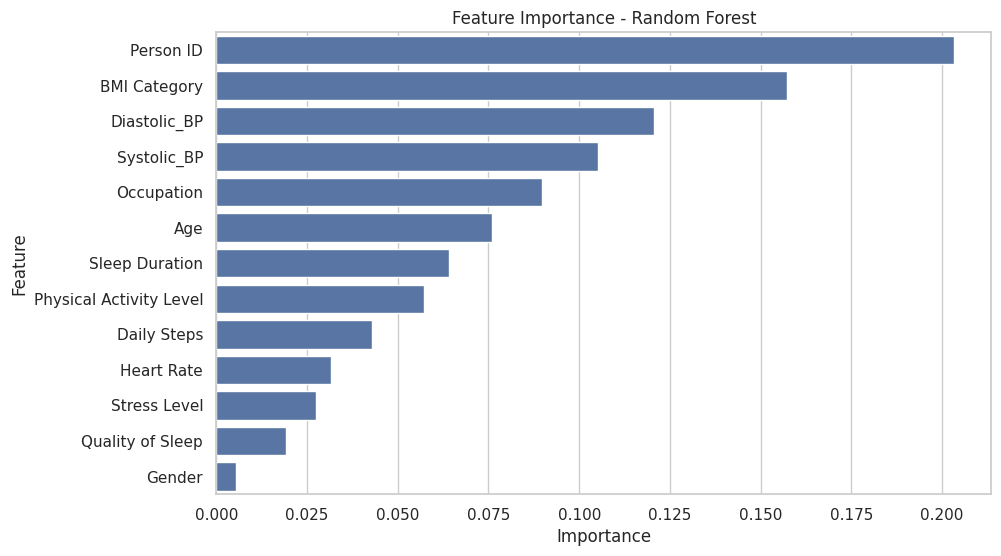

                    Feature  Importance
0                 Person ID    0.203436
8              BMI Category    0.157368
12             Diastolic_BP    0.120504
11              Systolic_BP    0.105054
3                Occupation    0.089866
2                       Age    0.075922
4            Sleep Duration    0.064144
6   Physical Activity Level    0.057131
10              Daily Steps    0.042828
9                Heart Rate    0.031637
7              Stress Level    0.027388
5          Quality of Sleep    0.019309
1                    Gender    0.005412


In [40]:
# 12. Feature Importance

importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()

print(importance_df)

In [41]:
# 13. Cross Validation

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.65333333 0.56       0.82666667 0.46666667 0.85135135]
Average CV Accuracy: 0.6716036036036036
